In [1]:
import os
from qiskit import QuantumCircuit
import sinter
from ldpc.sinter_decoders import SinterBeliefFindDecoder, SinterBpOsdDecoder

from src.stabilizer_code import extract, to_qiskit, bb_code
from src.simulate import tostim

from lib.TrapSIMD.sabre_iontrap import *
from lib.TrapSIMD.grid_iontrap import *

In [2]:
path = "./QEC-Code"

In [3]:
code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")
bb_code(stab_fname)

qasm_fname = os.path.join(path, f"{code_name}.qasm")
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=12)

(12, 72)


In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * 10 ** (-4)
    }
    return noise_profile 

In [5]:
noise_list = [2 * 10 ** (-4) / k for k in range(1, 10, 2)]
tasks = []

D = 8
L = 3
CZ = 3
draw_flag = False

code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")
bb_code(stab_fname)

qasm_fname = os.path.join(path, f"{code_name}.qasm")
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=12)

circ = QuantumCircuit.from_qasm_file(qasm_fname)
num_q = circ.num_qubits
num_s = circ.num_clbits

result_our_list, node_list = grid_compiler(D, L, CZ, circ, draw_flag)

for p in noise_list:
    circ = tostim(gen_noise_profile2(p), stabilizers, logicals, node_list, num_q, num_s)
    tasks.append(
        sinter.Task(circuit = circ, json_metadata={'r': 12, 'p': p})
)

(12, 72)


In [7]:
circ

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
    H 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107
    CX 20 110
    DEPOLARIZE2(0.00183) 20 110
    CX 21 111
    DEPOLARIZE2(0.00183) 21 111
    CX 22 112
    DEPOLARIZE2(0.00183) 22 112
    CX 23 113
    DEPOLARIZE2(0.00183) 23 113
    CX 24 114
    DEPOLARIZE2(0.00183) 24 114
    CX 25 115
    DEPOLARIZE2(0.00183) 25 115
    CX 26 116
    DEPOLARIZE2(0.00183) 26 116
    CX 28 118
    DEPOLARIZE2(0.00183) 28 118
    CX 29 119
    DEP

In [6]:
my_bp_method = "ms"
my_max_iter = 10000
my_osd_method = "osd_cs"
my_osd_order = 7
my_ms_scaling_factor = 0

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["bposd"],
    custom_decoders={
        "bposd": SinterBpOsdDecoder(
            max_iter=my_max_iter,
            bp_method=my_bp_method,
            ms_scaling_factor=my_ms_scaling_factor,
            osd_method=my_osd_method,
            osd_order=my_osd_order)
    },
    max_shots=1_000_000,
    print_progress=True,
)

Starting 4 workers...


ValueError: Worker failed: traceback=Traceback (most recent call last):
  File "/home/keyin/miniconda3/envs/qiskit-legacy/lib/python3.9/site-packages/sinter/_collection/_collection_worker_state.py", line 28, in _fill_in_task
    dem = circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
ValueError: An error case in a composite error exceeded the max supported number of symptoms (<=15).
The 4 basis error cases (e.g. X, Z) used to form the combined error cases (e.g. Y = X*Z) are:
0: D812
1: D833, D846, D847, D848, D857, D863
2: D826
3: D825, D831, D837, D840, D841, D842, D843, D851, D857, D858, L0


Circuit stack trace:
    at instruction #44466 [which is DEPOLARIZE2(4e-05) 28 130 93 87 76 22 28 89 0 74 136 96 27 114]

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/keyin/miniconda3/envs/qiskit-legacy/lib/python3.9/site-packages/sinter/_collection/_collection_worker_state.py", line 31, 

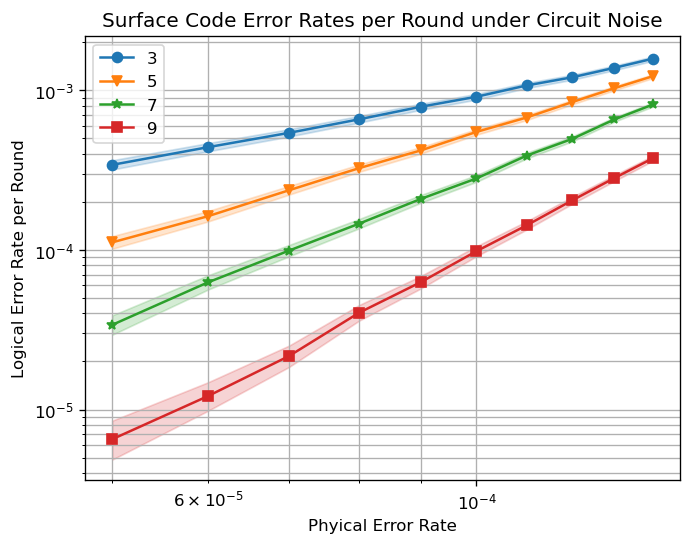

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stats: stats.json_metadata['p'],
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  